# Zero-shot candidate-action transfer to WCCI

This notebook compares the transferable, no-leakage candidate-action models trained on bus14 with the **do-nothing** policy on 50 WCCI test episodes without maintenance. No WCCI fine-tuning or retraining is used.

Model labels use the training abbreviations: `NL` = raw graph features, `NLS` = physical graph scaling, `mean`/`tmean` = joint/typed mean pooling, `f0`/`f1` = candidate features off/on, and `a0h0`/`a0h1` = dedicated action-0 head off/on.

In [1]:
from pathlib import Path
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from IPython.display import display

pd.set_option("display.max_columns", 40)

def find_task_dir(start=Path.cwd()):
    start = Path(start).resolve()
    for candidate in [start, *start.parents]:
        if candidate.name == "Topology_Task" and (candidate / "main.py").is_file():
            return candidate
        nested = candidate / "Topology_Task"
        if (nested / "main.py").is_file():
            return nested
    raise FileNotFoundError("Could not locate the Topology_Task directory.")

TASK_DIR = find_task_dir()
FULL_TEST_DIR = TASK_DIR / "outputs" / "full_test_eval"
MODEL_DIRS = {
    "NL": FULL_TEST_DIR / "NL_cas_hl_wcci36",
    "NLS": FULL_TEST_DIR / "NLS_cas_hl_wcci36",
}
DO_NOTHING_SUMMARY = (
    TASK_DIR / "outputs" / "do_nothing_eval" / "wcci_test_nomaint_50" / "do_nothing_summary.json"
)
EXPORT_CSV = FULL_TEST_DIR / "wcci36_zero_shot_vs_do_nothing.csv"
EXPORT_FIGURE = FULL_TEST_DIR / "wcci36_zero_shot_vs_do_nothing.png"

TASK_DIR

PosixPath('/Users/corentinplumet/Documents/RL_Marl2grid/Topology_Task')

## Load and validate the evaluations

The comparison uses mean normalized episode length, reported as survival percentage. The checks below reject evaluations from another environment, split, episode count, or transfer protocol.

In [2]:
RESULT_RE = re.compile(
    r"best_test_cas_hl_(?P<preprocessing>NL|NLS)(?:_izar)?_shared_"
    r"(?P<pool>mean|tmean)_f(?P<features>[01])_a0h(?P<a0_head>[01])_s(?P<seed>\d+)"
    r"_step(?P<step>\d+)_job(?P<job>\d+)\.json"
)

def load_json(path):
    with Path(path).open(encoding="utf-8") as handle:
        return json.load(handle)

rows = []
for expected_preprocessing, directory in MODEL_DIRS.items():
    if not directory.is_dir():
        raise FileNotFoundError(f"Missing model result directory: {directory}")
    for path in sorted(directory.glob("*.json")):
        match = RESULT_RE.fullmatch(path.name)
        if match is None:
            raise ValueError(f"Unrecognized result filename: {path.name}")
        factors = match.groupdict()
        result = load_json(path)
        assert factors["preprocessing"] == expected_preprocessing
        assert result.get("zero_shot_transfer") is True
        assert result.get("source_env_id") == "bus14"
        assert result.get("target_env_id") == "bus36_wcci_nomaint"
        assert result.get("split") == "test"
        assert result.get("split_chronics") is True
        assert result.get("eval_all_split_chronics") is False
        assert int(result.get("eval_episodes")) == 50
        assert result.get("deterministic_eval") is True
        assert result.get("eval_action_heuristic") == "none"
        expected_scaling = expected_preprocessing == "NLS"
        assert bool(result.get("gnn_physical_scaling_effective")) == expected_scaling

        pool_label = "Typed mean" if factors["pool"] == "tmean" else "Mean"
        config = f"{factors['pool']}_f{factors['features']}_a0h{factors['a0_head']}"
        rows.append({
            "preprocessing": factors["preprocessing"],
            "pool": factors["pool"],
            "pooling": pool_label,
            "features": bool(int(factors["features"])),
            "action0_head": bool(int(factors["a0_head"])),
            "seed": int(factors["seed"]),
            "checkpoint_step": int(result["checkpoint_global_step"]),
            "configuration": config,
            "label": f"{factors['preprocessing']} · {pool_label.lower()} · f{factors['features']} · a0h{factors['a0_head']}",
            "survival_percent": float(result["survival_percent"]),
            "result_file": str(path.relative_to(TASK_DIR)),
        })

models = pd.DataFrame(rows)
if models.empty:
    raise RuntimeError("No zero-shot WCCI evaluation summaries were found.")
if models.duplicated(["preprocessing", "configuration", "seed"]).any():
    raise ValueError("Duplicate evaluation summaries found for one experimental cell.")

do_nothing = load_json(DO_NOTHING_SUMMARY)
assert do_nothing.get("env_id") == "bus36_wcci_nomaint"
assert do_nothing.get("split") == "test"
assert do_nothing.get("split_chronics") is True
assert int(do_nothing.get("n_episodes")) == 50
assert int(do_nothing.get("chronic_split_seed")) == 0
do_nothing_percent = 100.0 * float(do_nothing["mean_survival"])

models["delta_vs_do_nothing"] = models["survival_percent"] - do_nothing_percent
models["beats_do_nothing"] = models["delta_vs_do_nothing"] > 0
models = models.sort_values("survival_percent", ascending=False).reset_index(drop=True)
models.to_csv(EXPORT_CSV, index=False)

print(f"Loaded {len(models)} model evaluations: {(models.preprocessing == 'NL').sum()} NL and {(models.preprocessing == 'NLS').sum()} NLS.")
print(f"Do-nothing mean survival: {do_nothing_percent:.2f}%")
print(f"Saved table: {EXPORT_CSV.relative_to(TASK_DIR)}")

Loaded 15 model evaluations: 7 NL and 8 NLS.
Do-nothing mean survival: 56.00%
Saved table: outputs/full_test_eval/wcci36_zero_shot_vs_do_nothing.csv


In [3]:
summary_table = models[[
    "preprocessing", "pooling", "features", "action0_head",
    "survival_percent", "delta_vs_do_nothing", "beats_do_nothing"
]].copy()
summary_table["features"] = summary_table["features"].map({False: "off", True: "on"})
summary_table["action0_head"] = summary_table["action0_head"].map({False: "off", True: "on"})
display(summary_table.style.format({
    "survival_percent": "{:.2f}%",
    "delta_vs_do_nothing": "{:+.2f} pp",
}))

,preprocessing,pooling,features,action0_head,survival_percent,delta_vs_do_nothing,beats_do_nothing
0,NLS,Typed mean,off,off,59.75%,+3.75 pp,True
1,NLS,Mean,on,off,57.66%,+1.66 pp,True
2,NL,Typed mean,off,on,54.99%,-1.01 pp,False
3,NL,Typed mean,on,on,38.95%,-17.06 pp,False
4,NLS,Typed mean,on,on,37.90%,-18.10 pp,False
5,NL,Mean,on,off,10.84%,-45.17 pp,False
6,NL,Typed mean,off,off,7.32%,-48.68 pp,False
7,NLS,Mean,on,on,1.26%,-54.74 pp,False
8,NL,Typed mean,on,off,1.21%,-54.80 pp,False
9,NLS,Typed mean,off,on,0.67%,-55.33 pp,False


## Survival against do-nothing

Bars show mean survival over 50 episodes. The annotation in parentheses is the difference from do-nothing in percentage points.

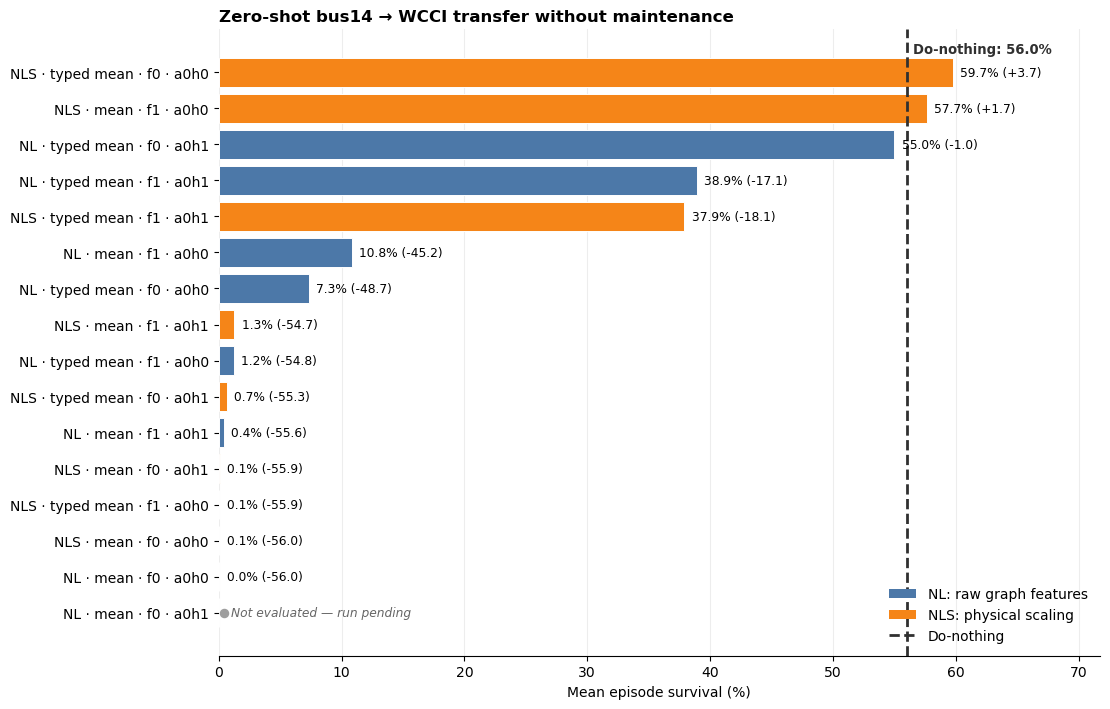

Saved figure: outputs/full_test_eval/wcci36_zero_shot_vs_do_nothing.png


In [4]:
completed_plot_data = models.sort_values("survival_percent", ascending=True).reset_index(drop=True)
pending_plot_data = pd.DataFrame([{
    "preprocessing": "pending",
    "label": "NL · mean · f0 · a0h1",
    "survival_percent": np.nan,
    "delta_vs_do_nothing": np.nan,
}])
# Keep the pending experiment visible without representing it as 0% survival.
plot_data = pd.concat([pending_plot_data, completed_plot_data], ignore_index=True)
colors = {"NL": "#4C78A8", "NLS": "#F58518", "pending": "#9E9E9E"}
bar_colors = plot_data["preprocessing"].map(colors)

fig, ax = plt.subplots(figsize=(11.2, 7.2))
bars = ax.barh(
    np.arange(len(plot_data)),
    plot_data["survival_percent"].fillna(0.0),
    color=bar_colors,
    edgecolor="white",
    linewidth=0.7,
)
ax.set_yticks(np.arange(len(plot_data)), labels=plot_data["label"])
ax.axvline(
    do_nothing_percent, color="#303030", linestyle="--", linewidth=2.0, zorder=3
)

x_max = max(70.0, float(plot_data["survival_percent"].max()) + 12.0)
ax.set_xlim(0, x_max)
for bar, value, delta in zip(
    bars, plot_data["survival_percent"], plot_data["delta_vs_do_nothing"]
):
    if pd.isna(value):
        y = bar.get_y() + bar.get_height() / 2
        ax.scatter(0.45, y, s=34, color=colors["pending"], zorder=4)
        ax.text(1.0, y, "Not evaluated — run pending", va="center", ha="left",
                fontsize=8.8, color="#666666", style="italic")
        continue
    ax.text(
        value + 0.6,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}% ({delta:+.1f})",
        va="center",
        ha="left",
        fontsize=8.8,
    )

ax.text(
    do_nothing_percent + 0.5,
    len(plot_data) - 0.15,
    f"Do-nothing: {do_nothing_percent:.1f}%",
    color="#303030",
    va="top",
    fontsize=9.5,
    fontweight="semibold",
)
ax.set_xlabel("Mean episode survival (%)")
ax.set_ylabel("")
ax.set_title("Zero-shot bus14 → WCCI transfer without maintenance", loc="left", fontweight="bold")
ax.grid(axis="x", alpha=0.22, linewidth=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.legend(
    handles=[
        Patch(facecolor=colors["NL"], label="NL: raw graph features"),
        Patch(facecolor=colors["NLS"], label="NLS: physical scaling"),
        Line2D([0], [0], color="#303030", linestyle="--", linewidth=2, label="Do-nothing"),
    ],
    loc="lower right",
    frameon=False,
)
fig.tight_layout()
fig.savefig(EXPORT_FIGURE, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved figure: {EXPORT_FIGURE.relative_to(TASK_DIR)}")

## Matched NL–NLS comparison

The table below isolates the effect of physical scaling where both preprocessing variants are available. A positive delta favors NLS.

In [5]:
paired = (
    models.pivot_table(
        index=["configuration", "pooling", "features", "action0_head"],
        columns="preprocessing",
        values="survival_percent",
        aggfunc="first",
    )
    .dropna(subset=["NL", "NLS"])
    .reset_index()
)
paired["NLS_minus_NL"] = paired["NLS"] - paired["NL"]
paired = paired.sort_values("NLS_minus_NL", ascending=False)
display(paired.style.format({"NL": "{:.2f}%", "NLS": "{:.2f}%", "NLS_minus_NL": "{:+.2f} pp"}))

preprocessing,configuration,pooling,features,action0_head,NL,NLS,NLS_minus_NL
3,tmean_f0_a0h0,Typed mean,False,False,7.32%,59.75%,+52.43 pp
1,mean_f1_a0h0,Mean,True,False,10.84%,57.66%,+46.83 pp
2,mean_f1_a0h1,Mean,True,True,0.39%,1.26%,+0.87 pp
0,mean_f0_a0h0,Mean,False,False,0.05%,0.05%,+0.00 pp
6,tmean_f1_a0h1,Typed mean,True,True,38.95%,37.90%,-1.05 pp
5,tmean_f1_a0h0,Typed mean,True,False,1.21%,0.06%,-1.14 pp
4,tmean_f0_a0h1,Typed mean,False,True,54.99%,0.67%,-54.32 pp


## Main observations

In [6]:
best = models.iloc[0]
best_nl = models.loc[models.preprocessing == "NL"].iloc[0]
n_above = int(models["beats_do_nothing"].sum())
print(
    f"Best zero-shot model: {best['label']} at {best['survival_percent']:.2f}% "
    f"({best['delta_vs_do_nothing']:+.2f} pp vs do-nothing)."
)
print(
    f"Best NL model: {best_nl['label']} at {best_nl['survival_percent']:.2f}% "
    f"({best_nl['delta_vs_do_nothing']:+.2f} pp vs do-nothing)."
)
print(f"{n_above} of {len(models)} zero-shot models outperform do-nothing on mean survival.")
print("Physical scaling is configuration-dependent: it produces the two strongest results, but it does not improve every matched architecture.")

Best zero-shot model: NLS · typed mean · f0 · a0h0 at 59.75% (+3.75 pp vs do-nothing).
Best NL model: NL · typed mean · f0 · a0h1 at 54.99% (-1.01 pp vs do-nothing).
2 of 15 zero-shot models outperform do-nothing on mean survival.
Physical scaling is configuration-dependent: it produces the two strongest results, but it does not improve every matched architecture.


### Comparability note

The available summaries match on environment (`bus36_wcci_nomaint`), test split, 50 episodes, deterministic actions, and absence of an evaluation heuristic. The do-nothing evaluation also records split seed 0. However, the downloaded model files contain aggregate summaries only; their referenced `episode_summary.csv` files are not present locally. Exact chronic-by-chronic fingerprint matching therefore cannot be rechecked until those episode files are downloaded.